In [1]:
from langchain_openai import ChatOpenAI
import os
from pydantic import SecretStr

llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(os.environ["OPENROUTER_API_KEY"]),
    temperature=0,
)   
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001CC5BA40C20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001CC5C472930>, root_client=<openai.OpenAI object at 0x000001CC59F2C6B0>

In [3]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="List of tasks to be performed")

llm_with_schema=llm.with_structured_output(llm_schema)

llm_with_schema.invoke("What is the list of tasks to be performed in a software development project?")

llm_schema(tasks=['Define project scope and objectives', 'Gather and analyze requirements', 'Create project plan and timeline', 'Design system architecture', 'Develop user interface (UI) and user experience (UX)', 'Write code for application features', 'Conduct unit testing and integration testing', 'Perform code reviews and quality assurance', 'Deploy application to production environment', 'Monitor application performance and user feedback', 'Implement maintenance and updates', 'Document code and project processes', 'Conduct user training and support', 'Manage project risks and issues', 'Communicate with stakeholders and team members'])

In [5]:
class graph_schema(TypedDict):
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

In [8]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator_worker(state: graph_schema) -> graph_schema:
    
    user_query = state["query"]
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator worker that performs tasks based on the user query."),
            ("user", "The user query is: {user_query}. "
                     "Please provide one prompt per task for the worker to follow.")
        ])

    chain= prompt | llm_with_schema

    response = chain.invoke({"user_query": user_query})

    state["tasks"] = response.tasks

    return state

In [10]:
obj=orchestrator_worker({
    "tasks": [],
    "query": "What are the steps to create a social media post about the beauty of nature?",
    "results": [],
    "summary": ""
})

obj["tasks"]

['Choose a specific aspect of nature to focus on (e.g., mountains, forests, oceans).',
 'Select a platform for the post (e.g., Instagram, Facebook, Twitter).',
 'Gather high-quality images or videos that showcase the beauty of the chosen aspect of nature.',
 'Write a captivating caption that reflects the beauty and significance of nature.',
 'Include relevant hashtags to increase visibility (e.g., #NatureLovers, #BeautifulDestinations).',
 "Schedule the post for optimal engagement time based on the platform's analytics.",
 'Engage with followers by responding to comments and encouraging them to share their own nature experiences.']

In [11]:
def execute(query:str):
    response = llm.invoke(f"Please execute the following query: {query}")
    return response


In [12]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:
    tasks = state["tasks"]
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        futures = executor.map(execute, tasks)
        for future in futures:
            results.append(future)

    state["results"] = results
    return state

In [ ]:
def collector_node(state: graph_schema) -> graph_schema:
    results = state["results"]
    
    summary_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results of executed tasks."),
            ("user", "The results of the executed tasks are: {results}. "
                     "Please provide a concise summary of these results.")
        ])

    chain = summary_prompt | llm

    response = chain.invoke({"results": results})

    state["summary"] = response.content
    return state 

In [15]:
from langgraph.graph import StateGraph, START, END

graph= StateGraph(graph_schema)

graph.add_node("orchestrator_worker", orchestrator_worker)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator_worker")
graph.add_edge("orchestrator_worker", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph=graph.compile()

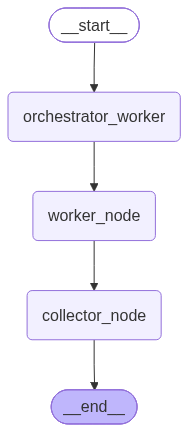

In [16]:
from IPython.display import display

display(complex_graph)